In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carregar todos os dados ATP (tour, qualifiers, challengers e futures)
# Carregar todos os dados ATP (tour, qualifiers, challengers e futures)
dfs = []
tournament_types = []  # Para rastrear o tipo de cada partida

for year in range(1992, 2025):
    # ATP Tour
    atp_tour = pd.read_csv(f'D:/projetos/Tenis ML-AI/data/tennis_atp/atp_matches_{year}.csv')
    atp_tour['tournament_type'] = 'ATP'
    dfs.append(atp_tour)
    
    # ATP Qualifiers/Challengers
    try:
        chall_qual = pd.read_csv(f'D:/projetos/Tenis ML-AI/data/tennis_atp/atp_matches_qual_chall_{year}.csv')
        chall_qual['tournament_type'] = 'CHALLENGER'
        dfs.append(chall_qual)
    except FileNotFoundError:
        print(f"Arquivo atp_matches_qual_chall_{year}.csv não encontrado, pulando...")
    
    # ATP Futures
    try:
        futures = pd.read_csv(f'D:/projetos/Tenis ML-AI/data/tennis_atp/atp_matches_futures_{year}.csv')
        futures['tournament_type'] = 'ITF'
        dfs.append(futures)
    except FileNotFoundError:
        print(f"Arquivo atp_matches_futures_{year}.csv não encontrado, pulando...")

# Concatenar todos os DataFrames
df = pd.concat(dfs, ignore_index=True)

# Definir as superfícies
surfaces = df['surface'].unique().tolist()
print("Superfícies encontradas:", surfaces)

# Parâmetros do ELO por tipo de torneio
K_FACTORS = {
    'ATP': 32,        # K-factor original para ATP
    'CHALLENGER': 24, # K-factor reduzido para Challengers
    'ITF': 16         # K-factor mais reduzido para ITF/Futures
}

INITIAL_ELO = 1500  # ELO inicial para todos os jogadores

# Dicionário para armazenar os ELOs por superfície
elo_by_surface = {}

# Inicializar ELOs para cada superfície
for surface in surfaces:
    if pd.isna(surface):
        continue
    elo_by_surface[surface] = {}

# Função para calcular a probabilidade esperada
def expected_score(elo_a, elo_b):
    return 1 / (1 + 10 ** ((elo_b - elo_a) / 400))

# Função para atualizar o ELO com K-factor variável
def update_elo(winner_elo, loser_elo, tournament_type):
    K = K_FACTORS.get(tournament_type, K_FACTORS['ITF'])  # Default para ITF se não encontrar
    expected_win = expected_score(winner_elo, loser_elo)
    change = K * (1 - expected_win)
    winner_elo += change
    loser_elo -= change
    return winner_elo, loser_elo

# Processar cada partida em ordem cronológica
df['tourney_date'] = pd.to_datetime(df['tourney_date'], format='%Y%m%d')
df = df.sort_values('tourney_date')

# Inicializar dicionário para armazenar o ELO atual de cada jogador por superfície
current_elo = {surface: {} for surface in elo_by_surface.keys()}

# Listas para armazenar os ELOs durante o processamento
winner_elos = []
loser_elos = []
k_factors_used = []  # Para tracking dos K-factors utilizados

for idx, row in df.iterrows():
    surface = row['surface']
    tournament_type = row['tournament_type']
    
    if pd.isna(surface):
        winner_elos.append(np.nan)
        loser_elos.append(np.nan)
        k_factors_used.append(np.nan)
        continue
    
    winner_id = row['winner_id']
    loser_id = row['loser_id']
    
    # Obter ELO atual ou usar o inicial
    winner_elo = current_elo[surface].get(winner_id, INITIAL_ELO)
    loser_elo = current_elo[surface].get(loser_id, INITIAL_ELO)
    
    # Armazenar ELOs antes da atualização
    winner_elos.append(winner_elo)
    loser_elos.append(loser_elo)
    k_factors_used.append(K_FACTORS.get(tournament_type, K_FACTORS['ITF']))
    
    # Atualizar ELOs com K-factor específico do tipo de torneio
    new_winner_elo, new_loser_elo = update_elo(winner_elo, loser_elo, tournament_type)
    
    # Atualizar no dicionário
    current_elo[surface][winner_id] = new_winner_elo
    current_elo[surface][loser_id] = new_loser_elo

# Adicionar colunas de ELO por superfície ao DataFrame
df['winner_surface_elo'] = winner_elos
df['loser_surface_elo'] = loser_elos
df['k_factor_used'] = k_factors_used

# Mostrar estatísticas dos K-factors utilizados
print("\nDistribuição dos K-factors utilizados:")
print(df['k_factor_used'].value_counts().sort_index())

print("\nDistribuição por tipo de torneio:")
print(df['tournament_type'].value_counts())

# Salvar os resultados
df.to_csv('atp_chall_itf_matches_with_surface_elo_variable_k.csv', index=False)

print(f"\nProcessamento concluído! {len(df)} partidas processadas.")
print(f"Arquivo salvo como: atp_chall_itf_matches_with_surface_elo_variable_k.csv")

# Opcional: Mostrar alguns exemplos dos ELOs finais por superfície
print("\n=== EXEMPLOS DE ELOs FINAIS POR SUPERFÍCIE ===")
for surface in list(current_elo.keys())[:3]:  # Mostrar apenas 3 superfícies
    if current_elo[surface]:
        print(f"\nTop 5 jogadores em {surface}:")
        sorted_players = sorted(current_elo[surface].items(), key=lambda x: x[1], reverse=True)[:5]
        for player_id, elo in sorted_players:
            print(f"  Jogador {player_id}: {elo:.2f}")

Superfícies encontradas: ['Hard', 'Carpet', 'Clay', 'Grass', nan]

Distribuição dos K-factors utilizados:
k_factor_used
16.0    489496
24.0    198783
32.0    104595
Name: count, dtype: int64

Distribuição por tipo de torneio:
tournament_type
ITF           489496
CHALLENGER    198783
ATP           104648
Name: count, dtype: int64

Processamento concluído! 792927 partidas processadas.
Arquivo salvo como: atp_chall_itf_matches_with_surface_elo_variable_k.csv

=== EXEMPLOS DE ELOs FINAIS POR SUPERFÍCIE ===

Top 5 jogadores em Hard:
  Jogador 206173: 2516.26
  Jogador 104925: 2408.07
  Jogador 103819: 2345.38
  Jogador 105223: 2266.45
  Jogador 207989: 2265.21

Top 5 jogadores em Carpet:
  Jogador 101948: 1870.86
  Jogador 103819: 1820.06
  Jogador 101414: 1812.71
  Jogador 105074: 1798.05
  Jogador 102338: 1792.01

Top 5 jogadores em Clay:
  Jogador 104925: 2349.50
  Jogador 104745: 2324.81
  Jogador 207989: 2309.04
  Jogador 126774: 2260.14
  Jogador 100644: 2249.48


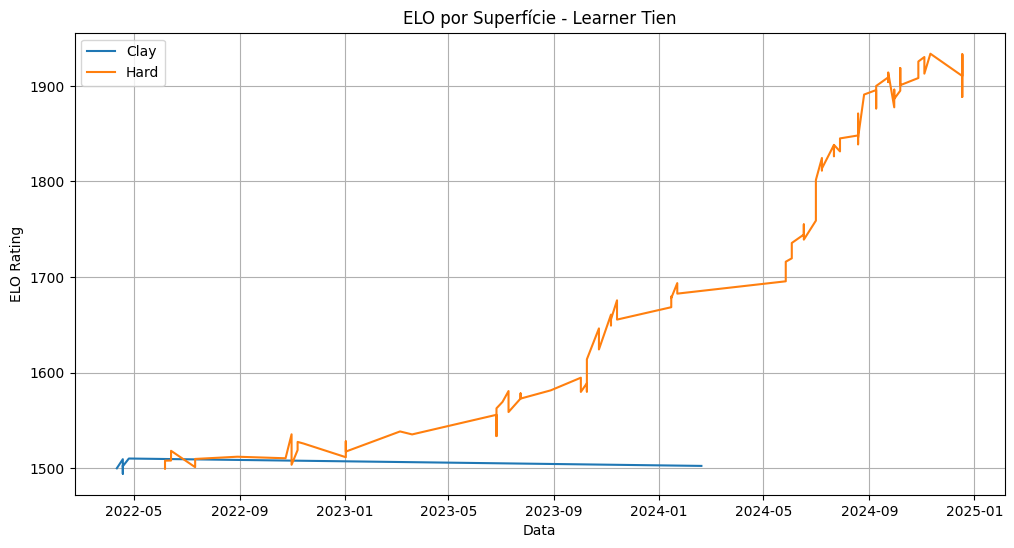

In [3]:
import matplotlib.pyplot as plt

# Exemplo: Pegar um jogador específico e plotar seu ELO por superfície ao longo do tempo
player_name = "Learner Tien"  # Substitua pelo nome do jogador desejado
player_id = df[df['winner_name'] == player_name]['winner_id'].iloc[0]

# Criar DataFrame com histórico do jogador
player_history = pd.concat([
    df[df['winner_id'] == player_id][['tourney_date', 'surface', 'winner_surface_elo']].rename(
        columns={'winner_surface_elo': 'surface_elo'}),
    df[df['loser_id'] == player_id][['tourney_date', 'surface', 'loser_surface_elo']].rename(
        columns={'loser_surface_elo': 'surface_elo'})
]).sort_values('tourney_date')

# Plotar
plt.figure(figsize=(12, 6))
for surface in player_history['surface'].unique():
    if pd.isna(surface):
        continue
    surface_data = player_history[player_history['surface'] == surface]
    plt.plot(surface_data['tourney_date'], surface_data['surface_elo'], label=surface)

plt.title(f'ELO por Superfície - {player_name}')
plt.xlabel('Data')
plt.ylabel('ELO Rating')
plt.legend()
plt.grid()
plt.show()
plt.close()